# The machines

Every board a node; a humanoid, a quad, a fixed wing, an e-bike over them; programs a model writes, streamed live behind a failsafe.

## 1 Setup

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

## 2 The nodes

`Nodes.discover` loads each installed board family - here `coaxial.node` - which finds its boards on every bus, each a node named by its bus and unit (`LL_2`); then the robot's other boards, a battery pack and a head camera. Each is asked what it offers first.

In [2]:
from machine.nodes import Nodes

nodes = Nodes.discover(port=PORT, simulated=SIMULATED)
kinds = sorted({n.type for n in nodes})
print('%d nodes: %s' % (len(nodes), ', '.join('%d %s' % (len(nodes.of_type(k)), k) for k in kinds)))
print(Nodes([nodes['battery'], nodes['head_camera']]).card())
offered = len(nodes.capabilities())
print(offered, 'channels in all')

22 nodes: 20 bldc_inverter, 1 bms, 1 camera
battery: bms simulated_bms, simulated unit 0
  in  pack.amps A, pack.cell_min V, pack.contactor 0/1, pack.soc 1, pack.temp C, pack.volts V
  out pack.contactor 0/1 0..1
head_camera: camera simulated_camera, simulated unit 0
  in  vision.target.seen 0/1, vision.target.x 1, vision.target.y 1
1890 channels in all


## 3 A humanoid, and what a model is told

`Machine(nodes, type='humanoid')`: a limb a bus, bus 1 the axis. Which board is which joint is measured: a ring test on each, the lowest ring innermost. The pack and camera are read beside; `prompt()` is what a model is told.

In [3]:
from machine import Machine

humanoid = Machine(nodes, type='humanoid')
for name in ('left_hip', 'left_knee', 'left_ankle', 'left_foot'):
    board = humanoid.actuators[name].node
    ring = board.identify()
    print('%-10s %s  %.1f Hz  J %.2g' % (name, board.name, ring['hz'], ring['j']))
told = humanoid.prompt()
print(told)
print('%d characters, about %d tokens' % (len(told), len(told) / 4))

left_hip   LL_1  24.1 Hz  J 3.2e-05
left_knee  LL_2  25.9 Hz  J 2.8e-05
left_ankle LL_3  30.0 Hz  J 2.1e-05
left_foot  LL_4  32.5 Hz  J 1.8e-05
One step a line: seconds, name=value; # a comment. A csv: names as columns.
  knee=40         a target: the step waits till it reads back (band=, 1 % of range)
  knee.deg.GE=38  waits till >= 38 instead (.LE <=)       n+=1  add to a counter
  seconds         the step time: past it an alarm, and on   wait=time  lasts it all
  knee.deg.H=60   alarm (.L below); .HH .LL trip to cleanup; from their row on
  label=up then=up else=down  go there when done / timed out (then no alarm)
  goto=up times=3  back 3 times    group=init | cleanup, runs always
  run=walk times=4 stride=25  a routine below, its params by name
0 seconds: a decision, no time passes. A jump to stop ends the program.

This machine (humanoid):
set  pelvis, waist, neck, head, left_shoulder, left_elbow, left_wrist, left_gripper, left_hip, left_knee, left_ankle, left_foot, right_shoulde

## 4 A program, as a model answers

Routines by name, and a search: the head turns 10 deg at a time until the camera sees the target, then 2 deg at a time until it is centred - a closed loop, as data.

In [4]:
PROGRAM = """
# squat twice, wave three times, then find the target and centre it
0 run=squat times=2
0 run=wave times=3
0 run=rest
0.3 label=scan head+=10 head_camera.vision.target.seen.GE=1 then=aim
0 goto=scan times=6
0.2 label=aim head+=2 head_camera.vision.target.x.LE=0.05 then=found
0 goto=aim times=20
0 label=found
0 run=stand
"""
out = humanoid.run(PROGRAM)
print(out.summary('head.deg', 'head_camera.vision.target.x', 'battery.pack.volts'))

done after 9.95 s, 43 steps
  row 0 0.73 s done
  row 1 0.73 s done
  row 2 0.73 s done
  row 3 0.69 s done
  row 4 0.56 s time
  row 5 0.56 s time
  row 6 0.56 s time
  row 7 0.56 s time
  row 8 0.56 s time
  row 9 0.56 s time
  ...
  row 16 0.00 s done
  end: head.deg 40.08, head_camera.vision.target.x -0.002604, battery.pack.volts 48.93


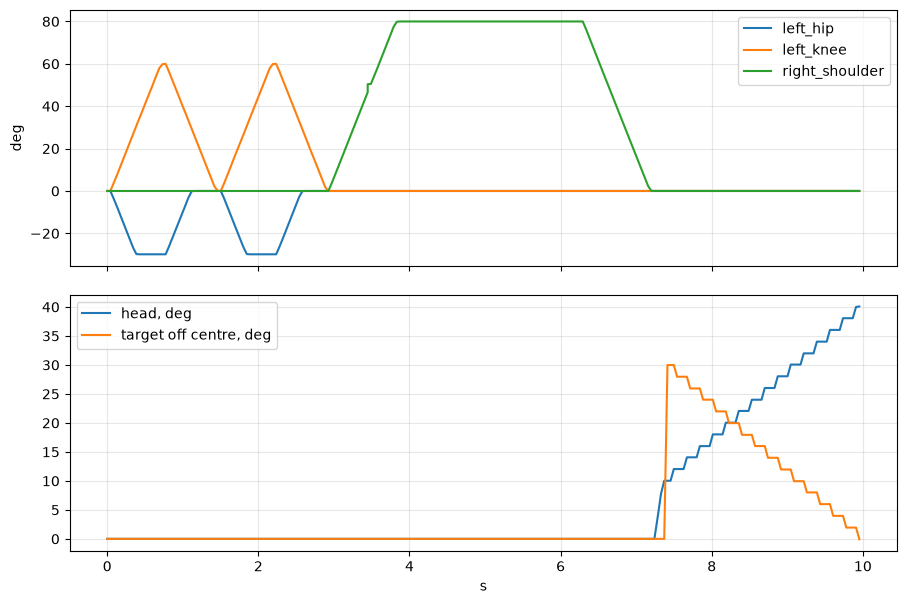

In [5]:
from coaxial.draw.figures import figure, show

t = [r['t'] for r in out.rows]
half = nodes['head_camera'].identity['fov'] / 2            # deg
fig, (joints, head) = figure(rows=2, sharex=True)
for joint in ('left_hip', 'left_knee', 'right_shoulder'):
    joints.plot(t, [r[joint + '.deg'] for r in out.rows], label=joint)
joints.set_ylabel('deg')
joints.legend(loc='upper right')
head.plot(t, [r['head.deg'] for r in out.rows], label='head, deg')
head.plot(t, [half * r['head_camera.vision.target.x'] for r in out.rows], label='target off centre, deg')
head.set_xlabel('s')
head.legend(loc='upper left')
show(fig)

## 5 When the model is wrong

Checked before anything arms, one line back: the routine meant, a parameter it does not take, a target out of range, a value that is not a number.

In [6]:
from machine.errors import MachineError

refusals = []
for wrong in ('0 run=wlak', '0 run=walk strides=3', '0 run=squat knee=120', '0.5 head=4O'):
    try:
        humanoid.run(wrong)
    except MachineError as exc:
        refusals.append(str(exc).splitlines()[-1])
        print('%-22s -> %s' % (wrong, refusals[-1]))

0 run=wlak             -> line 0: no routine wlak - did you mean walk? - there are stand, squat, walk, wave, look, rest
0 run=walk strides=3   -> line 0: walk takes stride, lift, period, not strides
0 run=squat knee=120   -> row 0: right_knee=120 is outside -90..90
0.5 head=4O            -> row 0: head=4O is not a number


## 6 Other machines, the same nodes

A type is data: the actuators it wants by kind, and its routines. The quad's rotors are speed loops (rpm), the fixed wing's surfaces narrow joints, the e-bike's assist a current.

In [7]:
from machine.sequencer import card

RUNS = {'quad': '0 run=take_off\n0 run=hover seconds=1\n0 run=yaw\n0 run=land',
        'fixed_wing': '0 run=take_off\n0 run=bank deg=-15\n0 run=land',
        'ebike': '0 run=assist amps=3 seconds=2\n0 run=coast'}
others = {}
for kind, steps in RUNS.items():
    craft = Machine(nodes, type=kind)
    print('%s, routines %s' % (kind, ', '.join(craft.routines)))
    print(card(craft.loop, craft.units, craft.ranges))
    others[kind] = craft.run(steps)
    print('  %s' % others[kind].summary().splitlines()[0])

quad, routines take_off, hover, yaw, pitch, land
set  rotor_fl, rotor_fr, rotor_rl, rotor_rr rpm 0..6000  (read back as <name>.rpm)


  done after 6.52 s, 6 steps
fixed_wing, routines take_off, cruise, bank, land
set  throttle rpm 0..6000  (read back as <name>.rpm)
set  aileron_l, aileron_r, elevator, rudder deg -25..25  (read back as <name>.deg)


  done after 8.60 s, 6 steps
ebike, routines assist, coast
set  assist A 0..5  (read back as <name>.amps)


  done after 2.36 s, 2 steps


## 7 Live: a line at a time, woken with a line

`feed` takes the answer as the model writes it: each finished line is checked and plays at once. `wait` returns one line when the buffer runs low or something happens, with what changed. Silence plays the type's failsafe.

In [8]:
import time
from machine.live import Live

ANSWER = ('0.5 left_knee=20 right_knee=20\n0 run=walk stride=15 period=0.25\n'
          '0 run=walk stride=15 period=0.25\n')
CPS = 160.0                                  # 40 tokens a second, 4 characters a token


def stream(live, fed):
    """Seconds from the answer's first token to the first move."""
    t0, first = time.monotonic(), None
    for i in range(0, len(ANSWER), 4):
        time.sleep(4 / CPS)
        if fed:
            live.feed(ANSWER[i:i + 4])
        if first is None and live.buffered() > 0:
            first = time.monotonic() - t0
    if not fed:
        live.send(ANSWER)
        first = time.monotonic() - t0
    return first


live = Live(humanoid, timeout=1.0, horizon=2.5).start()
first = {'whole': stream(live, fed=False)}
print(live.wait(low=0.0, timeout=6.0))
first['fed'] = stream(live, fed=True)
woke = live.wait(low=0.3, timeout=6.0)
print(woke)
print(live.feed('0.5 head=4O\n'))
print(live.wait(low=-1.0, timeout=6.0))
streamed = live.stop()
print('first move %.2f s fed, %.2f s whole; woken in %d tokens'
      % (first['fed'], first['whole'], len(woke) / 4))

low 0.00 s | now t=11.9 pelvis=0 waist=0 neck=0 head=0 left_shoulder=0 left_elbow=0 left_wrist=0 left_gripper=0 left_hip=15 left_knee=0 left_ankle=0 left_foot=0 right_shoulder=0 right_elbow=0 right_wrist=0 right_gripper=0 right_hip=-15 right_knee=0 right_ankle=0 right_foot=0 battery.pack.amps=2.25 battery.pack.cell_min=4.09 battery.pack.contactor=1 battery.pack.soc=0.891 battery.pack.temp=26.1 battery.pack.volts=49.1 head_camera.vision.target.seen=0 head_camera.vision.target.x=0 head_camera.vision.target.y=0


low 0.26 s | now t=13.7 left_hip=0 right_hip=0 right_knee=15 battery.pack.soc=0.89
['refused: row 0: head=4O is not a number']


failsafe: nothing sent for 1.00 s | now t=13.9 left_hip=15 right_hip=-15 right_knee=0


first move 0.21 s fed, 0.67 s whole; woken in 20 tokens


## 8 Through the board chat

The `program` tool is what the local model calls on its session: `card` once, `run` a whole program (its summary back), or live - `start`, `send`, `wait`, `stop` - each reply a line.

In [9]:
from coaxial.comm.session import open_session
from coaxial_mcp.tools import close_programs, program

session, _ = open_session(PORT, simulated=SIMULATED)
print(program(session, op='run', machine='quad', text='0 run=take_off\n0 run=land'))
calls = [('start', ''), ('send', '0 run=take_off seconds=0.5\n0 run=hover seconds=0.8'),
         ('wait', ''), ('stop', '')]
replies = [program(session, op=op, machine='quad', text=text) for op, text in calls]
for (op, _), reply in zip(calls, replies):
    print('%-5s %3d tokens  %s' % (op, len(reply) / 4, reply[:70]))
close_programs(session)
nodes.close()

done after 3.89 s, 4 steps
  row 0 0.61 s done
  row 1 0.98 s timeout
  row 2 1.19 s done
  row 3 1.10 s done
  1 alarm: row 1: timeout after 1 s - rotor_fl.rpm 3217 of 3500, rotor_fr.rpm 3215 of 3500, rotor_rl.rpm 3211 of 3500, rotor_rr.rpm 3207 of 3500


start  80 tokens  started, failsafe 0 run=land | now t=3.9 rotor_fl=44 rotor_fr=50 rotor
send    5 tokens  queued, 1.80 s to play
wait   52 tokens  alarm row 1: timeout after 0.5 s - rotor_fl.rpm 2629 of 3500, rotor_fr
stop   17 tokens  stopped | now t=6.8 rotor_fl=-13 rotor_fr=-1 rotor_rl=22 rotor_rr=48


## 9 Results

In [10]:
print('1. nodes      %d; %d channels offered' % (len(nodes), offered))
print('2. the prompt %d characters for %d joints and their routines' % (len(told), len(humanoid.actuators)))
print('3. the run    %s, %d steps; the target %.2f of the half field off centre'
      % (out.status, len(out.steps), abs(out.rows[-1]['head_camera.vision.target.x'])))
print('4. refused    %d of 4, each in a line' % len(refusals))
print('5. others     %s' % ', '.join('%s %s' % (k, o.status) for k, o in others.items()))
print('6. live       first move %.2f s fed, %.2f s sent whole; woken in %d tokens; %s'
      % (first['fed'], first['whole'], len(woke) / 4, streamed['status']))
print('7. the chat   %s' % ', '.join('%s %d' % (op, len(r) / 4) for (op, _), r in zip(calls, replies)))

1. nodes      22; 1890 channels offered
2. the prompt 1450 characters for 20 joints and their routines
3. the run    done, 43 steps; the target 0.00 of the half field off centre
4. refused    4 of 4, each in a line
5. others     quad done, fixed_wing done, ebike done
6. live       first move 0.21 s fed, 0.67 s sent whole; woken in 20 tokens; stopped
7. the chat   start 80, send 5, wait 52, stop 17


- The model writes lines and names routines, not code: the sequencer runs, the loop holds.
- A wrong line costs one line back; silence costs the failsafe; a limit trips.
- A line moves the machine once written; a wait costs a line: what happened, what moved.

**Bench.** Discover through the broker, the pack and camera given as `peripherals`; arming empty (the STO chain released); every joint commissioned and its span set; the failsafe a routine that is safe from anywhere.

## References

* `host/machine/nodes.py` - `Node`, `Nodes`, `FAMILIES`: boards as IO nodes, capabilities first
* `host/machine/machine.py` - `Machine`: actuators over nodes; `discover`, `prompt`, `run`
* `host/coaxial/node.py` - the Coaxial63100 family: its node, joint, surface, rotor, torque
* `host/machine/routines.py` - the types and their routines
* `host/machine/live.py` - `Live`: chunks, a buffer, a watchdog, a failsafe
* `host/machine/sequencer.py` - lines or tables; `check`, `summary`, `card`, `GRAMMAR`
* `host/coaxial_mcp/tools.py` - `program`, `close_programs`: the board-chat tool
* `host/coaxial/comm/session.py` - `open_session`: the board, or its stand-in